## Phase 2 Extension: 70-30 vs 80-20

This notebook is organized around three claims:

1. **Parameter shift across environments**: compare fitted RFLR parameters in 70-30 vs 80-20 and check whether the main change is in `alpha` (stickiness), while `beta` and `tau` are relatively stable.
2. **Behavioral evaluation by numbers**: focus on two key metrics only, `switches` and `reward_per_switch` (70-30 vs 80-20), reported as tables and tests.
3. **Motivation for extension**: use a single scatter view (`switches` vs `reward_per_switch`) to motivate testing a dynamic-`alpha` model in noisier environments.


In [1]:
# Imports and paths
import os, sys
import numpy as np
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

cwd = os.getcwd()
if os.path.exists(os.path.join(cwd, "reproduction", "2ABT_behaviour_models_updated")):
    PROJECT_ROOT = cwd
elif os.path.exists(
    os.path.join(cwd, "..", "reproduction", "2ABT_behaviour_models_updated")
):
    PROJECT_ROOT = os.path.abspath(os.path.join(cwd, ".."))
else:
    raise FileNotFoundError(
        "Could not locate reproduction/2ABT_behaviour_models_updated"
    )

BEHAV_DIR = os.path.join(PROJECT_ROOT, "reproduction", "2ABT_behaviour_models_updated")
if BEHAV_DIR not in sys.path:
    sys.path.insert(0, BEHAV_DIR)

import model_simulations as sim
import model_fitting as fit

OUTDIR = os.path.join(PROJECT_ROOT, "Extensions", "phase2_generative")
os.makedirs(OUTDIR, exist_ok=True)

np.random.seed(0)

/opt/homebrew/Caskroom/miniconda/base/envs/py311/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Load mouse data (REAL sessions + REAL latent states from Target)
df = pd.read_csv(os.path.join(BEHAV_DIR, "bandit_data.csv")).copy()

# Keep only the two conditions
df = df[df["Condition"].isin(["70-30", "80-20"])].copy()

# Sort - sessions are in correct trial order
df = df.sort_values(["Session", "Trial"])
# Ensure trials are chronological within each session


def build_sessions_and_states(df_cond):
    mouse_sessions = []  # list of choices, rewards
    state_sessions = []  # list of state arrays (Target)
    meta = []  # Mouse, Session

    for sess, g in df_cond.groupby("Session"):
        # g = one session worth of trials
        choices = g["Decision"].astype(int).to_numpy()  # Choice per trial
        rewards = g["Reward"].astype(int).to_numpy()  # Reward per trial
        states = (
            g["Target"].astype(int).to_numpy()
        )  # True latent correct side per trial

        mouse_sessions.append((choices, rewards))  # Store mouse behaviour
        state_sessions.append(states)  # Store the true state sequence
        meta.append((g["Mouse"].iloc[0], sess))  # Mouse ID and session ID

    return mouse_sessions, state_sessions, meta


df80 = df[df["Condition"] == "80-20"].copy()  # Subset to 80-20
df70 = df[df["Condition"] == "70-30"].copy()  # Subset to 70-30

mouse_sessions_80, states_80_real, meta_80 = build_sessions_and_states(df80)
mouse_sessions_70, states_70_real, meta_70 = build_sessions_and_states(df70)

len(mouse_sessions_80), len(mouse_sessions_70), len(states_80_real), len(states_70_real)

FileNotFoundError: [Errno 2] No such file or directory: '/Users/lenkaokasova/Documents/GitHub/Stochastic Switching Bandits Project/reproduction/2ABT_behaviour_models_updated/bandit_data.csv'

In [ ]:
# Fit RFLR on Mouse 80-20 and 70-30 - real data

# Fit on 80-20
rflr_params_80, nll_80 = fit.fit_with_sgd(
    fit.log_probability_rflr,  # Objective: log probability under RFLR
    mouse_sessions_80,  # Data: choices and rewards from mice in 80-20
    num_steps=4000,  # SGD iterations
    step_size=1e-2,  # Learning rate
    init_parameters=(0.0, 1.0, 2.0),  # Starting guess for alpha, beta and tau
)
alpha_80, beta_80, tau_80 = np.asarray(rflr_params_80, dtype=float).reshape(-1)[:3]

# Fit on 70-30
rflr_params_70, nll_70 = fit.fit_with_sgd(
    fit.log_probability_rflr,
    mouse_sessions_70,  # Data: mice in 70-30
    num_steps=4000,
    step_size=1e-2,
    init_parameters=(0.0, 1.0, 2.0),
)
alpha_70, beta_70, tau_70 = np.asarray(rflr_params_70, dtype=float).reshape(-1)[:3]

(alpha_80, beta_80, tau_80), (alpha_70, beta_70, tau_70), (nll_80, nll_70)

iteration  0 neg ll:  0.25747707
iteration  1000 neg ll:  0.18779886
iteration  2000 neg ll:  0.18509173
iteration  3000 neg ll:  0.1840569
iteration  0 neg ll:  0.30199584
iteration  1000 neg ll:  0.20443213
iteration  2000 neg ll:  0.2003353
iteration  3000 neg ll:  0.1991485


((np.float64(0.7112466096878052),
  np.float64(1.6068638563156128),
  np.float64(1.982416033744812)),
 (np.float64(0.9394705295562744),
  np.float64(1.6236896514892578),
  np.float64(2.0656580924987793)),
 (0.18341244757175446, 0.19851545989513397))

In [ ]:
# Parameter comparison: 70-30 vs 80-20
param_table = pd.DataFrame(
    [
        {
            "condition": "80-20",
            "alpha": alpha_80,
            "beta": beta_80,
            "tau": tau_80,
            "mean_nll": float(nll_80),
        },
        {
            "condition": "70-30",
            "alpha": alpha_70,
            "beta": beta_70,
            "tau": tau_70,
            "mean_nll": float(nll_70),
        },
    ]
)

wide = param_table.set_index("condition")[["alpha", "beta", "tau"]]
delta = (wide.loc["70-30"] - wide.loc["80-20"]).rename("delta_70_minus_80")
pct = (((wide.loc["70-30"] - wide.loc["80-20"]) / wide.loc["80-20"]) * 100).rename(
    "pct_change_vs_80"
)

param_compare = pd.concat([delta, pct], axis=1)

print("Fitted parameter table:")
display(param_table)
print("\nDifference summary (70-30 minus 80-20):")
display(param_compare)

Fitted parameter table:


,condition,alpha,beta,tau,mean_nll
0,80-20,0.711247,1.606864,1.982416,0.183412
1,70-30,0.939471,1.623690,2.065658,0.198515



Difference summary (70-30 minus 80-20):


,delta_70_minus_80,pct_change_vs_80
alpha,0.228224,32.087875
beta,0.016826,1.047120
tau,0.083242,4.199021


In [ ]:
# 5-fold CV (session-level) for train/test-consistent parameter comparison
from sklearn.model_selection import KFold


def run_rflr_cv(sessions, condition, n_splits=5, seed=11):
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=seed)
    rows = []

    for fold, (train_idx, test_idx) in enumerate(kf.split(sessions), start=1):
        train_data = [sessions[i] for i in train_idx]
        test_data = [sessions[i] for i in test_idx]

        params, train_nll = fit.fit_with_sgd(
            fit.log_probability_rflr,
            train_data,
            init_parameters=(0.0, 1.0, 2.0),
            num_steps=4000,
            step_size=1e-2,
        )
        alpha, beta, tau = np.asarray(params, dtype=float).reshape(-1)[:3]
        test_mean_ll = float(fit.log_probability_rflr((alpha, beta, tau), test_data))

        rows.append(
            {
                "condition": condition,
                "fold": fold,
                "alpha": alpha,
                "beta": beta,
                "tau": tau,
                "train_mean_nll": float(train_nll),
                "test_mean_ll": test_mean_ll,
                "test_mean_nll": -test_mean_ll,
                "n_train_sessions": len(train_data),
                "n_test_sessions": len(test_data),
            }
        )

    return pd.DataFrame(rows)


cv_80 = run_rflr_cv(mouse_sessions_80, "80-20")
cv_70 = run_rflr_cv(mouse_sessions_70, "70-30")
cv_results = pd.concat([cv_80, cv_70], ignore_index=True)

cv_param_summary = cv_results.groupby("condition", as_index=False).agg(
    alpha_mean=("alpha", "mean"),
    alpha_sd=("alpha", "std"),
    beta_mean=("beta", "mean"),
    beta_sd=("beta", "std"),
    tau_mean=("tau", "mean"),
    tau_sd=("tau", "std"),
    test_mean_nll_mean=("test_mean_nll", "mean"),
    test_mean_nll_sd=("test_mean_nll", "std"),
)

cv_results.to_csv(
    os.path.join(OUTDIR, "rflr_cv_fold_results_70_30_vs_80_20.csv"), index=False
)
cv_param_summary.to_csv(
    os.path.join(OUTDIR, "rflr_cv_param_summary_70_30_vs_80_20.csv"), index=False
)

print("Fold-level CV results:")
display(cv_results)
print("\nCV parameter summary by condition:")
display(cv_param_summary)

iteration  0 neg ll:  0.25784305
iteration  1000 neg ll:  0.18879795
iteration  2000 neg ll:  0.18615212
iteration  3000 neg ll:  0.18513647
iteration  0 neg ll:  0.25551924
iteration  1000 neg ll:  0.18360494
iteration  2000 neg ll:  0.18080005
iteration  3000 neg ll:  0.17975529
iteration  0 neg ll:  0.26018998
iteration  1000 neg ll:  0.19152856
iteration  2000 neg ll:  0.18881716
iteration  3000 neg ll:  0.18777809
iteration  0 neg ll:  0.25645432
iteration  1000 neg ll:  0.1867392
iteration  2000 neg ll:  0.18400429
iteration  3000 neg ll:  0.18295743
iteration  0 neg ll:  0.25740036
iteration  1000 neg ll:  0.18830821
iteration  2000 neg ll:  0.185658
iteration  3000 neg ll:  0.18462566
iteration  0 neg ll:  0.3007071
iteration  1000 neg ll:  0.20110312
iteration  2000 neg ll:  0.19683334
iteration  3000 neg ll:  0.19560799
iteration  0 neg ll:  0.30293557
iteration  1000 neg ll:  0.2065552
iteration  2000 neg ll:  0.20260444
iteration  3000 neg ll:  0.20147337
iteration  0 neg l

,condition,fold,alpha,beta,tau,train_mean_nll,test_mean_ll,test_mean_nll,n_train_sessions,n_test_sessions
0,80-20,1,0.701830,1.607337,1.980151,0.184498,-0.179174,0.179174,127,32
1,80-20,2,0.720977,1.623322,1.993232,0.179105,-0.200928,0.200928,127,32
2,80-20,3,0.719894,1.586479,1.981014,0.187144,-0.168971,0.168971,127,32
3,80-20,4,0.717284,1.602188,1.985173,0.182310,-0.187814,0.187814,127,32
4,80-20,5,0.696233,1.615411,1.972742,0.183970,-0.181126,0.181126,128,31
5,70-30,1,0.960468,1.620693,2.083327,0.194965,-0.212426,0.212426,160,40
6,70-30,2,0.925675,1.620593,2.066426,0.200870,-0.189842,0.189842,160,40
7,70-30,3,0.949672,1.618094,2.064326,0.199966,-0.192097,0.192097,160,40
8,70-30,4,0.926109,1.629728,2.052109,0.198896,-0.196987,0.196987,160,40
9,70-30,5,0.935359,1.629725,2.062225,0.197807,-0.201330,0.201330,160,40



CV parameter summary by condition:


,condition,alpha_mean,alpha_sd,beta_mean,beta_sd,tau_mean,tau_sd,test_mean_nll_mean,test_mean_nll_sd
0,70-30,0.939457,0.015254,1.623767,0.005539,2.065683,0.011291,0.198536,0.008947
1,80-20,0.711244,0.011402,1.606947,0.013978,1.982462,0.007504,0.183603,0.011808


In [ ]:
# Statistical test: is alpha different between 70-30 and 80-20?
from scipy.stats import mannwhitneyu, ttest_ind

alpha_70 = cv_results.loc[cv_results["condition"] == "70-30", "alpha"].to_numpy()
alpha_80 = cv_results.loc[cv_results["condition"] == "80-20", "alpha"].to_numpy()

mean_70 = float(alpha_70.mean())
mean_80 = float(alpha_80.mean())
delta_alpha = mean_70 - mean_80

# Nonparametric and Welch tests over fold-level alpha estimates
mw = mannwhitneyu(alpha_70, alpha_80, alternative="two-sided")
tt = ttest_ind(alpha_70, alpha_80, equal_var=False)

# Bootstrap CI for mean difference (70-30 minus 80-20)
rng = np.random.default_rng(0)
B = 20000
boot = np.empty(B, dtype=float)
for b in range(B):
    b70 = rng.choice(alpha_70, size=len(alpha_70), replace=True)
    b80 = rng.choice(alpha_80, size=len(alpha_80), replace=True)
    boot[b] = b70.mean() - b80.mean()
ci_low, ci_high = np.quantile(boot, [0.025, 0.975])

# Effect size (Cohen's d)
s_pooled = np.sqrt(((alpha_70.var(ddof=1) + alpha_80.var(ddof=1)) / 2.0))
cohens_d = delta_alpha / s_pooled if s_pooled > 0 else np.nan

alpha_diff = pd.DataFrame(
    [
        {
            "mean_alpha_70": mean_70,
            "mean_alpha_80": mean_80,
            "delta_alpha_70_minus_80": delta_alpha,
            "mw_u": float(mw.statistic),
            "mw_p": float(mw.pvalue),
            "welch_t": float(tt.statistic),
            "welch_p": float(tt.pvalue),
            "ci95_low": float(ci_low),
            "ci95_high": float(ci_high),
            "cohens_d": float(cohens_d),
            "n_folds_per_condition": int(len(alpha_70)),
        }
    ]
)

alpha_diff.to_csv(
    os.path.join(OUTDIR, "alpha_difference_test_70_30_vs_80_20.csv"), index=False
)
alpha_diff

,mean_alpha_70,mean_alpha_80,delta_alpha_70_minus_80,mw_u,mw_p,welch_t,welch_p,ci95_low,ci95_high,cohens_d,n_folds_per_condition
0,0.939457,0.711244,0.228213,25.0,0.007937,26.795578,1.206249e-08,0.213954,0.243626,16.947012,5


In [ ]:
# Estimate p_switch from real Target sequences
def estimate_p_switch(state_sessions):
    # probability that Target changes from t to t+1
    changes = 0
    total = 0
    for s in state_sessions:
        if len(s) < 2:
            continue  # Skip tiny sessions
        changes += (s[1:] != s[:-1]).sum()  # Count state flips
        total += len(s) - 1  # Total transitions
    return changes / total if total > 0 else np.nan


p_switch_80 = estimate_p_switch(states_80_real)  # Empirical flip rate in 80-20
p_switch_70 = estimate_p_switch(states_70_real)  # Empirical flip rate in 70-30

p_switch_80, p_switch_70

(np.float64(0.01965436313206742), np.float64(0.02006180821350988))

In [ ]:
# Simulate RFLR generatively on real state sequences
from scipy.special import expit as sigmoid


def run_rflr_on_states(states_list, alpha, beta, tau, p_reward):
    alpha = float(np.asarray(alpha).reshape(-1)[0])
    beta = float(np.asarray(beta).reshape(-1)[0])
    tau = float(np.asarray(tau).reshape(-1)[0])

    gamma = np.exp(-1.0 / tau)
    sessions = []

    for states in states_list:
        states = np.asarray(states, dtype=int)
        T = len(states)

        choices = np.zeros(T, dtype=int)
        rewards = np.zeros(T, dtype=int)
        psis = np.zeros(T, dtype=float)

        choices[0] = np.random.randint(2)
        rewards[0] = int(
            np.random.rand() < (p_reward if choices[0] == states[0] else 1 - p_reward)
        )
        phi = beta * rewards[0] * (2 * choices[0] - 1)

        for t in range(1, T):
            psi = phi + alpha * (2 * choices[t - 1] - 1)
            psis[t] = psi
            choices[t] = int(np.random.rand() < sigmoid(psi))
            rewards[t] = int(
                np.random.rand()
                < (p_reward if choices[t] == states[t] else 1 - p_reward)
            )
            phi = gamma * phi + beta * rewards[t] * (2 * choices[t] - 1)

        sessions.append([choices, rewards, psis])

    return sessions


rflr_80 = run_rflr_on_states(states_80_real, alpha_80, beta_80, tau_80, p_reward=0.8)
rflr_70 = run_rflr_on_states(states_70_real, alpha_70, beta_70, tau_70, p_reward=0.7)

len(rflr_80), len(rflr_70)

(159, 200)

In [ ]:
# Simulate HMM Thompson Sampling on REAL state sequences (ideal observer)
def run_hmm_sessions(states_list, p_reward, p_switch):
    mouse = sim.BayesianMouse({"p_switch": p_switch, "p_reward": p_reward})
    return sim.simulate_experiment(
        params={"p_reward": p_reward},
        mouse=mouse,
        states=states_list,
        policy="thompson",
        sticky=False,
    )


hmm_80 = run_hmm_sessions(states_80_real, p_reward=0.8, p_switch=p_switch_80)
hmm_70 = run_hmm_sessions(states_70_real, p_reward=0.7, p_switch=p_switch_70)

len(hmm_80), len(hmm_70)

(159, 200)

In [ ]:
# Simulate Sticky / Cost-Gated HMM on real state sequences
def run_sticky_sessions(states_list, p_reward, p_switch, alpha, beta, tau):
    alpha = float(np.asarray(alpha).reshape(-1)[0])
    beta = float(np.asarray(beta).reshape(-1)[0])
    tau = float(np.asarray(tau).reshape(-1)[0])

    clean_states = []
    for s in states_list:
        a = np.asarray(s, dtype=int)
        if a.ndim == 1:
            clean_states.append(a)
        elif a.ndim == 2 and 1 in a.shape:
            clean_states.append(a.reshape(-1))
        else:
            raise ValueError(
                f"Expected 1D state sequence per session, got shape {a.shape}"
            )

    mouse = sim.BayesianMouse(
        {
            "p_switch": p_switch,
            "p_reward": p_reward,
            "alpha": alpha,
            "beta": beta,
            "tau": tau,
        }
    )
    return sim.simulate_experiment(
        params={"p_reward": p_reward},
        mouse=mouse,
        states=clean_states,
        policy="stochastic",
        sticky=True,
    )

In [ ]:
# Metric Extraction (key metrics only)


def metrics(sessions):
    rows = []
    for c, r, *_ in sessions:
        switches = np.sum(c[1:] != c[:-1])
        rows.append(
            {
                "reward_per_switch": r.sum() / max(1, switches),
                "switches": switches,
            }
        )
    return pd.DataFrame(rows)


summary = pd.concat(
    [
        metrics(mouse_sessions_80).assign(model="Mouse", cond="80-20"),
        metrics(mouse_sessions_70).assign(model="Mouse", cond="70-30"),
        metrics(hmm_80).assign(model="HMM", cond="80-20"),
        metrics(hmm_70).assign(model="HMM", cond="70-30"),
        metrics(rflr_80).assign(model="RFLR", cond="80-20"),
        metrics(rflr_70).assign(model="RFLR", cond="70-30"),
        metrics(sticky_80).assign(model="Sticky HMM", cond="80-20"),
        metrics(sticky_70).assign(model="Sticky HMM", cond="70-30"),
    ],
    ignore_index=True,
)

summary.head()

,reward_per_switch,switches,model,cond
0,7.397059,68,Mouse,80-20
1,9.500000,60,Mouse,80-20
2,10.384615,52,Mouse,80-20
3,13.209302,43,Mouse,80-20
4,12.868421,38,Mouse,80-20


In [ ]:
from scipy.stats import mannwhitneyu


def fdr_bh(pvals):
    pvals = np.asarray(pvals, dtype=float)
    n = len(pvals)
    order = np.argsort(pvals)
    ranked = pvals[order]
    adj = ranked * n / (np.arange(1, n + 1))
    adj = np.minimum.accumulate(adj[::-1])[::-1]
    adj = np.clip(adj, 0, 1)
    out = np.empty_like(adj)
    out[order] = adj
    return out


key_metrics = ["switches", "reward_per_switch"]
models_cond = ["Mouse", "HMM", "RFLR", "Sticky HMM"]

cond_rows = []
for m in models_cond:
    d = summary[summary["model"] == m]
    for met in key_metrics:
        x70 = d.loc[d["cond"] == "70-30", met].dropna().values
        x80 = d.loc[d["cond"] == "80-20", met].dropna().values
        U, p = mannwhitneyu(x70, x80, alternative="two-sided")
        cond_rows.append(
            {
                "model": m,
                "metric": met,
                "U": U,
                "p": p,
                "med_70": np.median(x70),
                "med_80": np.median(x80),
                "n_70": len(x70),
                "n_80": len(x80),
            }
        )

cond_compare = pd.DataFrame(cond_rows)
cond_compare["p_fdr"] = fdr_bh(cond_compare["p"].values)
cond_compare = cond_compare.sort_values(["metric", "p_fdr"])

print("Condition comparison for key metrics only (70-30 vs 80-20):")
cond_compare

Condition comparison for key metrics only (70-30 vs 80-20):


,model,metric,U,p,med_70,med_80,n_70,n_80,p_fdr
3,HMM,reward_per_switch,192.0,3.426220e-58,2.588642,4.661017,200,159,2.740976e-57
7,Sticky HMM,reward_per_switch,8801.5,3.672410e-13,16.533482,21.304348,200,159,9.793094e-13
5,RFLR,reward_per_switch,11360.0,3.357248e-06,8.569843,9.383333,200,159,6.714496e-06
1,Mouse,reward_per_switch,13496.5,1.388392e-02,9.148148,10.716981,200,159,1.851189e-02
2,HMM,switches,30317.5,2.605138e-49,181.000000,113.000000,200,159,1.042055e-48
6,Sticky HMM,switches,19942.0,3.457351e-05,29.000000,25.000000,200,159,5.531762e-05
0,Mouse,switches,16808.0,3.527558e-01,52.000000,48.000000,200,159,4.031495e-01
4,RFLR,switches,16331.0,6.592666e-01,55.000000,55.000000,200,159,6.592666e-01


Mean key metrics by model/condition:


,model,cond,switches,reward_per_switch
0,HMM,70-30,181.595000,2.651646
1,HMM,80-20,114.018868,4.747256
2,Mouse,70-30,51.600000,11.959709
3,Mouse,80-20,49.044025,12.665735
4,RFLR,70-30,54.810000,8.733513
5,RFLR,80-20,54.320755,9.775476
6,Sticky HMM,70-30,29.670000,17.538711
7,Sticky HMM,80-20,26.056604,22.387199



Median key metrics by model/condition:


,model,cond,switches,reward_per_switch
0,HMM,70-30,181.0,2.588642
1,HMM,80-20,113.0,4.661017
2,Mouse,70-30,52.0,9.148148
3,Mouse,80-20,48.0,10.716981
4,RFLR,70-30,55.0,8.569843
5,RFLR,80-20,55.0,9.383333
6,Sticky HMM,70-30,29.0,16.533482
7,Sticky HMM,80-20,25.0,21.304348


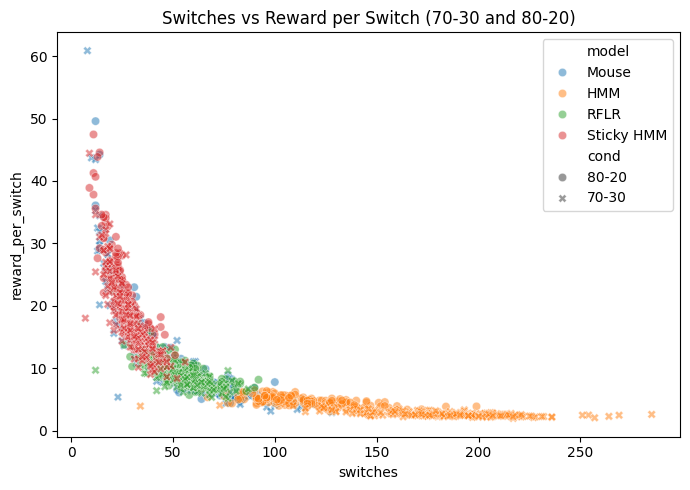

In [ ]:
# Key metric tables (numbers only) + one scatter to motivate dynamic alpha
key_metrics = ["switches", "reward_per_switch"]

metric_means = (
    summary.groupby(["model", "cond"], as_index=False)[key_metrics]
    .mean()
    .sort_values(["model", "cond"])
)
metric_medians = (
    summary.groupby(["model", "cond"], as_index=False)[key_metrics]
    .median()
    .sort_values(["model", "cond"])
)

metric_means.to_csv(
    os.path.join(OUTDIR, "key_metrics_means_by_model_condition.csv"), index=False
)
metric_medians.to_csv(
    os.path.join(OUTDIR, "key_metrics_medians_by_model_condition.csv"), index=False
)

print("Mean key metrics by model/condition:")
display(metric_means)
print("\nMedian key metrics by model/condition:")
display(metric_medians)

# Single scatter: switches vs reward_per_switch (for intuition/motivation)
plt.figure(figsize=(7, 5))
sns.scatterplot(
    data=summary,
    x="switches",
    y="reward_per_switch",
    hue="model",
    style="cond",
    alpha=0.5,
)
plt.title("Switches vs Reward per Switch (70-30 and 80-20)")
plt.tight_layout()
plt.savefig(
    os.path.join(OUTDIR, "scatter_switches_vs_reward_per_switch.png"),
    dpi=300,
    bbox_inches="tight",
)
plt.show()